# Pre-series04-Python

## Import libraries

In [14]:
import numpy as np 
import matplotlib.pyplot as plt

# 1. Generate a known signal 

Equation of a sinusoid at 1Hz, with amplitude 1 and phase 0 :
$$s(t) = A\sin(2\pi f t + \varphi),\quad A=1,\ f=1\,\text{Hz},\ \varphi=0 \;\Rightarrow\; s(t)=\sin(2\pi t)$$

We build a 3D signal $(x, y, z)$ from the same 1 Hz sinusoid, with a constant phase shift $\Delta\varphi = \pi/4$ applied successively from one axis to the next: $y$ is shifted by $\Delta\varphi$ relative to $x$, and $z$ is shifted by $\Delta\varphi$ relative to $y$. Therefore, $z$ is shifted by $2\Delta\varphi = \pi/2$ relative to $x$:

$$x(t)=\sin(2\pi t),\quad y(t)=\sin\!\left(2\pi t+\tfrac{\pi}{4}\right),\quad z(t)=\sin\!\left(2\pi t+\tfrac{\pi}{2}\right)$$

In general, for axis $k \in \{0, 1, 2\}$ (x, y, z): $s_k(t) = \sin(2\pi t + k\,\Delta\varphi)$. This is implemented with `phases = phi0 + phase_shift * np.arange(3)`, and NumPy broadcasting applies one phase per column of `time` (shape `(n, 1)`).

In [15]:
# Parameters 

f = 1.0                 # frequency (Hz)
A = 1.0                 # amplitude
phi0 = 0.0              # initial phase (rad)
n_samples = 100       # number of samples
duration = 3.0          # duration (s)
phase_shift = np.pi / 4 # phase shift between x->y and y->z (rad)

# Time vector

time = np.linspace(0, duration, n_samples).reshape(-1, 1)   # shape (n, 1)

# Signal (x, y, z) in columns

phases = phi0 + phase_shift * np.arange(3)           # [0, pi/4, pi/2]
signal = A * np.sin(2 * np.pi * f * time + phases)   # broadcasting -> (n, 3)

# Check 

print(f"t.shape = {time.shape}")
print(f"s.shape = {signal.shape}")
print(f"phase_shift = {phase_shift/np.pi:g} pi")



t.shape = (100, 1)
s.shape = (100, 3)
phase_shift = 0.25 pi


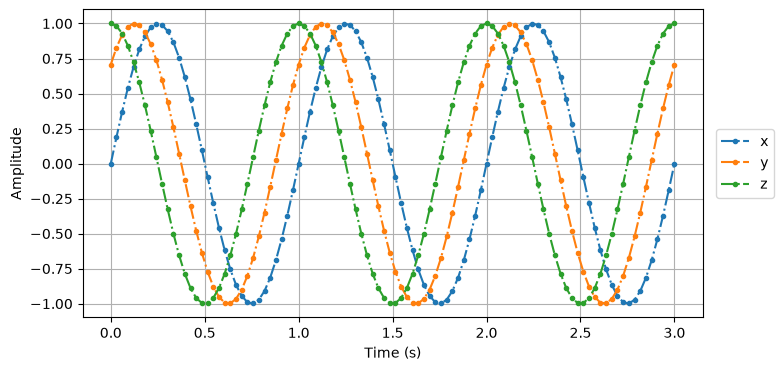

In [16]:
# Plot 2D figure 

fig2d, ax = plt.subplots(figsize=(8, 4))
for i, name in enumerate("xyz"):
    ax.plot(time, signal[:, i], ".-.", label=name)   # points reliés en pointillés
ax.set_xlabel("Time (s)")
ax.set_ylabel("Amplitude")
ax.grid(True)
ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5))
plt.show()

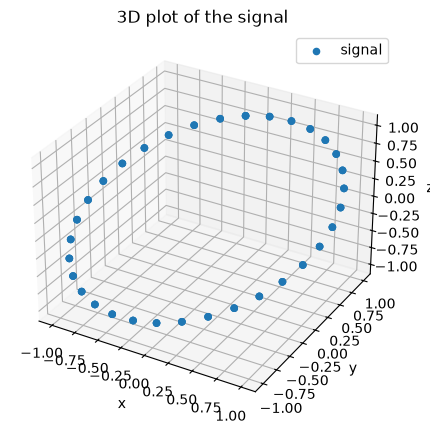

In [17]:
# Plot 3D figure

fig3d = plt.figure(figsize=(6, 5))
ax3 = fig3d.add_subplot(projection="3d")
ax3.scatter(signal[:, 0], signal[:, 1], signal[:, 2], label="signal")
ax3.set_xlabel("x"); ax3.set_ylabel("y"); ax3.set_zlabel("z")
ax3.set_title("3D plot of the signal")
ax3.legend()
plt.show()

# 2. Estimate the time derivative of the signal 

## 2.1 Derivative of a sine wave 

Let $s(t)=A\sin(\theta(t))$ with $\theta(t)=2\pi f t+\varphi$, so that $\theta'(t)=2\pi f$.
We use Euler's formulas from the mathematical analysis course (eq. 1.40 and 1.41, §1.5.2 of reference 1):

$$\sin\theta=\frac{e^{i\theta}-e^{-i\theta}}{2i},\qquad \cos\theta=\frac{e^{i\theta}+e^{-i\theta}}{2}$$

and the derivative of a complex exponential, $\dfrac{d}{dt}e^{\pm i\theta(t)}=\pm i\,\theta'(t)\,e^{\pm i\theta(t)}$. Then

$$\frac{ds}{dt}=A\,\frac{i\theta'e^{i\theta}+i\theta'e^{-i\theta}}{2i}
=A\,\theta'\,\frac{e^{i\theta}+e^{-i\theta}}{2}
=2\pi f\,A\cos(2\pi f t+\varphi)$$

Applied to each axis of our signal ($A=1$, $f=1$ Hz, phases $0,\ \pi/4,\ \pi/2$):

$$\frac{dx}{dt}=2\pi\cos(2\pi t),\quad
\frac{dy}{dt}=2\pi\cos\!\left(2\pi t+\tfrac{\pi}{4}\right),\quad
\frac{dz}{dt}=2\pi\cos\!\left(2\pi t+\tfrac{\pi}{2}\right)$$

The derivative of a sine is a cosine, i.e. a sine **advanced by $\pi/2$**, with an amplitude multiplied by $2\pi f$.


## 2.2 Forward vs. central difference

In practice we only have samples $s_i = s(t_i)$, so the derivative is approximated by a finite difference
(reference 2).

**Forward difference** uses the current sample and the next one:

$$\dot s_i \approx \frac{s_{i+1}-s_i}{t_{i+1}-t_i}$$

**Central difference** uses the samples before and after the current one:

$$\dot s_i \approx \frac{s_{i+1}-s_{i-1}}{t_{i+1}-t_{i-1}}$$

Differences between the two methods (with a step $h = t_{i+1}-t_i$), from the Taylor expansion $s(t+h)=s(t)+h\,s'(t)+\tfrac{h^2}{2}s''(t)+\tfrac{h^3}{6}s'''(t)+\dots$:

- **Accuracy:** the forward difference has an error of order $O(h)$ (the $s''$ term remains). In the central difference, the $s''$ terms cancel, so the error is of order $O(h^2)$.
- **Time localisation:** the forward estimate is really the slope between $t_i$ and $t_{i+1}$ (it is centred at $t_i+h/2$, hence a small time lag). The central estimate is centred exactly at $t_i$.
- **Edges:** the forward difference needs the *next* sample, so it is undefined for the last sample. The central difference needs both neighbours, so it is undefined for the first and the last samples. To keep the output the same shape as the input, we use one-sided differences at the borders (see 3.3).
- **Noise:** both amplify noise, the central difference slightly less since it averages over a wider window.

## 2.3 Function design

- **Input order: `(signal, time)`.** The signal is the main object we operate on, and the time vector is the coordinate along which we differentiate. This is the same convention as `np.gradient(f, x)` or `np.trapz(y, x)`. Both arrays have the samples over rows (axis 0), so `signal` is `(n, d)` and `time` is `(n, 1)` and they broadcast together.
- **Output shape: `(n, d)`**, the same as `signal`: one derivative value per sample and one column per dimension, so that the derivative can be plotted or combined with the signal directly. The two methods give $n-1$ and $n-2$ estimates by definition, so the borders are completed with one-sided differences:
  - forward difference: the last sample reuses the last interval (backward difference);
  - central difference: the first sample uses a forward difference and the last sample a backward difference (same behaviour as `np.gradient`).

In [18]:
# See reference 2 for the finite-difference formulas (forward, backward, central):

def forward_difference(signal, time):
    """Time derivative with the forward difference.

    signal : (n, d) array, samples over rows, dimensions over columns
    time   : (n, 1) array (or (n,)), measurement dates over rows
    returns: (n, d) array. Row i uses samples i and i+1.
             The last row has no "next" sample: it reuses the last interval
             (i.e. a backward difference), so the output keeps the shape of `signal`.
    """
    signal = np.asarray(signal, dtype=float)
    time = np.asarray(time, dtype=float).reshape(-1, 1)
    assert signal.shape[0] == time.shape[0], "signal and time must have the same number of samples"
    d = np.diff(signal, axis=0) / np.diff(time, axis=0)    # (n-1, d)
    return np.vstack([d, d[-1:]])                          # (n, d)

def central_difference(signal, time):
    """Time derivative with the central difference.

    signal : (n, d) array, samples over rows, dimensions over columns
    time   : (n, 1) array (or (n,)), measurement dates over rows
    returns: (n, d) array. Interior rows use samples i-1 and i+1.
             The first row uses a forward difference and the last row a
             backward difference (no neighbour on one side), so the output
             keeps the shape of `signal`.
    """
    signal = np.asarray(signal, dtype=float)
    time = np.asarray(time, dtype=float).reshape(-1, 1)
    assert signal.shape[0] == time.shape[0], "signal and time must have the same number of samples"
    d = np.empty_like(signal)
    d[1:-1] = (signal[2:] - signal[:-2]) / (time[2:] - time[:-2])
    d[0] = (signal[1] - signal[0]) / (time[1] - time[0])
    d[-1] = (signal[-1] - signal[-2]) / (time[-1] - time[-2])
    return d

# Apply the finite-difference formulas to the signal

d_fwd = forward_difference(signal, time)
d_cen = central_difference(signal, time)
print(f"signal : {signal.shape}   forward : {d_fwd.shape}   central : {d_cen.shape}")

# Sanity check against the analytical derivative:
d_true = 2 * np.pi * f * A * np.cos(2 * np.pi * f * time + phases)
print("max abs error, forward :", np.abs(d_fwd - d_true).max().round(3))
print("max abs error, central :", np.abs(d_cen - d_true).max().round(3))

signal : (100, 3)   forward : (100, 3)   central : (100, 3)
max abs error, forward : 0.597
max abs error, central : 0.596


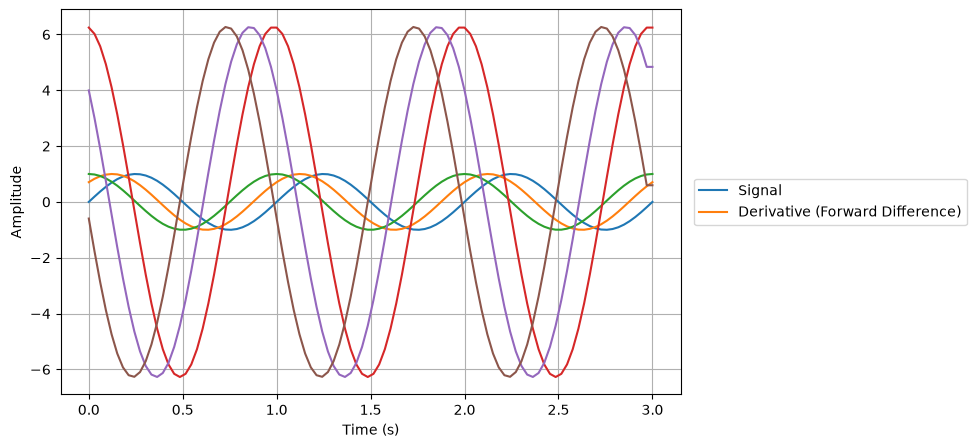

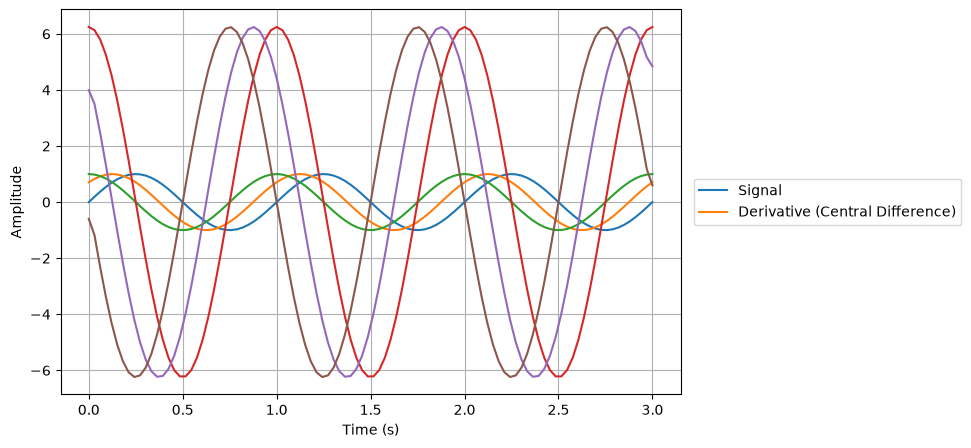

In [19]:
# Plots : signal and derivative on the same axes

from matplotlib.lines import Line2D
def plot_signal_and_derivative(signal, deriv, time, method):
    fig, ax = plt.subplots(figsize=(8, 5))
    for i in range(3):
        ax.plot(time, signal[:, i], color=f"C{i}")        # signal: C0, C1, C2
    for i in range(3):
        ax.plot(time, deriv[:, i], color=f"C{i + 3}")     # derivative: C3, C4, C5
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Amplitude")
    ax.grid(True)
    handles = [Line2D([], [], color="C0", label="Signal"),
               Line2D([], [], color="C1", label=f"Derivative ({method})")]
    ax.legend(handles=handles, loc="center left", bbox_to_anchor=(1.01, 0.5))
    plt.show()

plot_signal_and_derivative(signal, d_fwd, time, "Forward Difference")
plot_signal_and_derivative(signal, d_cen, time, "Central Difference")

# 3 Estimate the tangential speed of the signal 

## 4.1 Tangential velocity vs. tangential speed

- The **velocity** is a **vector**: the time derivative of the position, $\vec v(t)=\dfrac{d\vec r}{dt}$. It tells *how fast* and *in which direction* the object moves, and it is always tangent to the trajectory (for a circular motion, tangent to the circle: this is the "tangential velocity") [3].
- The **tangential speed** is a **scalar**: the *magnitude* (norm) of that vector, $v(t)=\lVert\vec v(t)\rVert=\dfrac{ds}{dt}$, where $s$ is the distance travelled along the path. It is always $\geq 0$ and has no direction [3, 4]. For a circular motion of radius $r$ and angular speed $\omega$: $v=\omega r$.

Example: moving at $-2$ m/s along an axis has a velocity of $-2$ m/s (it goes backwards) but a speed of $2$ m/s.

Reference number 1

## 4.2 Tangential speed of a 3D movement

For a small displacement $(dx, dy, dz)$, Pythagoras gives the travelled distance $ds^2=dx^2+dy^2+dz^2$. Dividing by $dt^2$ and taking the square root:

$$v(t)=\frac{ds}{dt}=\sqrt{\left(\frac{dx}{dt}\right)^2+\left(\frac{dy}{dt}\right)^2+\left(\frac{dz}{dt}\right)^2}=\sqrt{\dot x^2+\dot y^2+\dot z^2}$$

Reference number 1 and 4 

### 4.3 Tangential speed of an nD movement

For a position $\vec r(t)=(x_1(t),\dots,x_n(t))$, the same reasoning gives the Euclidean norm of the velocity vector:

$$v(t)=\lVert\dot{\vec r}(t)\rVert_2=\sqrt{\sum_{k=1}^{n}\dot x_k(t)^2}$$

The 2D case is the modulus of a complex number, $|z|=\sqrt{a^2+b^2}$ (eq. 1.15 of [1]), applied to $\dot x+i\,\dot y$.
In a "4D time series" (3 spatial dimensions + time), time is the independent variable used for the derivative, **not** a fourth component of the norm: the signal has $n=3$ columns and `time` is a separate array.

Reference number 1 and 4

### 4.4 Function design

The speed is computed in two steps: (1) the velocity vector of each sample, with the `central_difference` function of section 3 (the most accurate of our two methods), then (2) its Euclidean norm across the columns (`np.linalg.norm(..., axis=1)`).

- **Input order: `(signal, time)`**, the same as in section 3, for consistency (and as in `np.gradient(f, x)`): the data first, then the coordinate along which we differentiate. `signal` is `(n, d)` with samples over rows, `time` is `(n, 1)`.
- **Output shape: `(n, 1)`**: one scalar speed per sample (the dimensions are collapsed by the norm), kept as a column so that the samples stay over rows like for `time` and `signal`. The borders use the one-sided differences of section 3.



In [20]:

def tangential_speed(signal, time):
    """Tangential speed of a movement: norm of the time derivative of its position.

    signal : (n, d) array, samples over rows, dimensions over columns (d = 1, 2, 3, ... n)
    time   : (n, 1) array (or (n,)), measurement dates over rows
    returns: (n, 1) array, one non-negative speed per sample
    """
    signal = np.asarray(signal, dtype=float)
    if signal.ndim == 1:                                  # a 1D signal given as (n,)
        signal = signal.reshape(-1, 1)
    velocity = central_difference(signal, time)           # (n, d): velocity vector
    return np.linalg.norm(velocity, axis=1, keepdims=True)   # (n, 1): sqrt(sum of squares)


# --- Apply to the signal of section 2 ---
speed = tangential_speed(signal, time)
speed_true = 2 * np.pi * f * A * np.sqrt(np.sum(np.cos(2 * np.pi * f * time + phases) ** 2,
                                                axis=1, keepdims=True))
print("speed.shape =", speed.shape)
print("max abs error vs analytical speed (interior samples):",
      np.abs(speed[1:-1] - speed_true[1:-1]).max().round(4))


speed.shape = (100, 1)
max abs error vs analytical speed (interior samples): 0.0536


## 4.5 Tests

For each test, the expected speed is computed by hand from the formula of 4.3 **before** running the code:

| Test | Movement | Velocity | Expected speed |
|---|---|---|---|
| 1D, uniform | $x=3t+1$ | $\dot x=3$ | $3$ |
| 1D, backwards | $x=-2t$ | $\dot x=-2$ | $\lvert-2\rvert=2$ |
| 1D, accelerated | $x=t^2$ | $\dot x=2t$ | $2t$ |
| 2D, circle | $(R\cos\omega t,\ R\sin\omega t)$ | $(-R\omega\sin\omega t,\ R\omega\cos\omega t)$ | $R\omega\sqrt{\sin^2+\cos^2}=R\omega$ |
| 3D, line | $(1,2,2)\,t$ | $(1,2,2)$ | $\sqrt{1+4+4}=3$ |
| 3D, helix | $(R\cos\omega t,\ R\sin\omega t,\ ct)$ | $(-R\omega\sin\omega t,\ R\omega\cos\omega t,\ c)$ | $\sqrt{R^2\omega^2+c^2}$ |
| 4D, line | $(1,1,1,1)\,t$ | $(1,1,1,1)$ | $\sqrt{4}=2$ |
| 6D, line | $(1,2,2,4,4,8)\,t$ | $(1,2,2,4,4,8)$ | $\sqrt{1+4+4+16+16+64}=\sqrt{105}$ |
| any, still | constant position | $\vec 0$ | $0$ |

The central difference is exact for polynomials of degree $\leq 2$, so lines and parabolas are compared exactly. The circle and the helix are only approximated (error in $O(h^2)$), so they are compared with a tolerance, on interior samples only (the borders use one-sided differences). We also check the output shape for $d=1,2,3,4,7$, a non-uniform time vector, and that the speed is never negative.

In [21]:
# --- Tests: each expected value is derived by hand (see the markdown above) ---
# The central difference is exact for polynomials of degree <= 2 (interior samples),
# so tests on lines / parabolas use exact comparisons; curved motions use a tolerance.
t = np.linspace(0, 2, 201).reshape(-1, 1)
inner = slice(1, -1)          # interior samples (the borders use one-sided differences)

# 0. Output shape is (n, 1) whatever the number of dimensions
for d in (1, 2, 3, 4, 7):
    assert tangential_speed(np.random.rand(len(t), d), t).shape == (len(t), 1)

# 1. 1D, uniform motion: x = 3t + 1  ->  v = 3
assert np.allclose(tangential_speed(3 * t + 1, t), 3)

# 2. 1D, negative velocity: x = -2t  ->  velocity = -2 but speed = |-2| = 2
assert np.allclose(tangential_speed(-2 * t, t), 2)

# 3. 1D, accelerated motion: x = t^2  ->  v = 2t
assert np.allclose(tangential_speed(t ** 2, t)[inner], 2 * t[inner])

# 4. 2D, uniform circular motion: (R cos wt, R sin wt)  ->  v = R w
R, w = 2.0, 3.0
t_fine = np.linspace(0, 2, 2001).reshape(-1, 1)
circle = np.hstack([R * np.cos(w * t_fine), R * np.sin(w * t_fine)])
assert np.allclose(tangential_speed(circle, t_fine)[inner], R * w, rtol=1e-4)

# 5. 3D, straight line: r = (1, 2, 2) t  ->  v = sqrt(1 + 4 + 4) = 3
assert np.allclose(tangential_speed(t * np.array([1, 2, 2]), t), 3)

# 6. 3D, helix: (R cos wt, R sin wt, c t)  ->  v = sqrt((R w)^2 + c^2)
c = 1.5
helix = np.hstack([circle, c * t_fine])
assert np.allclose(tangential_speed(helix, t_fine)[inner], np.sqrt((R * w) ** 2 + c ** 2), rtol=1e-4)

# 7. 4D and 6D, straight lines: (1, 1, 1, 1) t -> v = 2 ; (1, 2, 2, 4, 4, 8) t -> sqrt(105)
assert np.allclose(tangential_speed(t * np.ones(4), t), 2)
assert np.allclose(tangential_speed(t * np.array([1, 2, 2, 4, 4, 8]), t), np.sqrt(105))

# 8. No movement: constant position -> v = 0
assert np.allclose(tangential_speed(np.full((len(t), 3), 5.0), t), 0)

# 9. Non-uniform sampling: a straight line is still exact
t_irr = np.sort(np.random.default_rng(0).uniform(0, 2, 100)).reshape(-1, 1)
assert np.allclose(tangential_speed(t_irr * np.array([1, 2, 2]), t_irr), 3)

# 10. Speed is never negative
assert (tangential_speed(np.random.rand(50, 3), np.linspace(0, 1, 50)) >= 0).all()

print("All tangential speed tests passed.")

All tangential speed tests passed.


# 5. Create an interactive plot with the plotly library
## 5.1 Install plotly

`matplotlib` produces static images. [Plotly](https://plotly.com/python/) draws the figure with JavaScript, so we can zoom, pan and hover over the data, in the notebook **and** in an exported HTML file. 

In [1]:
# Install plotly (only needed once, can be commented out afterwards)
%pip install plotly

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip
